In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

DF = pd.read_csv(r"D:\OneDrive\Desktop\Statistics RnW\PR. 1\expectation_decider_dataset.csv")
DF.head()

# ****1. Understanding the Basics of Probability****

# **Probability is the measure of how likely an event is to occur.**

# *The value of probability ranges from 0 to 1.*

### **Key Probability Terminology**

# **Experiment:** A process that produces an outcome.
# **Outcome:** The result of an experiment.
# **Event:** A specific outcome or group of outcomes.
# **Sample Space:** The set of all possible outcomes.
# **Joint Probability:** Probability that two events occur together.
# **Marginal Probability:** Probability of a single event.
# **Conditional Probability:** Probability of one event given that another event has occurred.

### **Probability Events from the Dataset**

# ******1. Probability that a student studies more than 10 hours and fails.******

In [4]:
a = len(DF[(DF["study_hours"] > 10) & (DF["final_exam_pass"] == "Fail")])

b = len(DF)

p = a / b

print("Probability:", p)

Probability: 0.32


# ****2. Probability of failing the exam.****

In [5]:
a = len(DF[DF["final_exam_pass"] == "Fail"])

b = len(DF)

p = a / b

print("Probability:", p)

Probability: 0.715


In [6]:
# **3. Probability of passing the exam.**

In [7]:
a = len(DF[DF["final_exam_pass"] == "Pass"])

b = len(DF)

p = a / b

print("Probability:", p)

Probability: 0.285


## ****Types of Events****

# **1. Empirical probability**

# Empirical probability is calculated from the actual observations in the dataset.

# Formula:

# P(Event) = Number of favorable outcomes / Total number of outcomes

In [9]:
sample = DF.sample(100, random_state=42)

# Calculating probability of passing
a = len(sample[sample["final_exam_pass"] == "Pass"])

b = len(sample)

p = a / b

print("Empirical Probability of Passing:", p)

Empirical Probability of Passing: 0.28


In [10]:
a = len(DF[DF["final_exam_pass"] == "Pass"])

b = len(DF)

p = a / b

print("Theoretical Probability of Passing:", p)

Theoretical Probability of Passing: 0.285


## ****3. Random Variable and Probability Distribution.****

# Let X be the number of students who pass the final exam out of 3 randomly selected students.

# Therefore, X can have the following values:

# X = 0, 1, 2, 3

# **Where:**

# X = 0 means no student passes.

# X = 1 means one student passes.

# X = 2 means two students pass.

# X = 3 means all three students pass.

In [29]:
p = DF["final_exam_pass"].value_counts(normalize=True)["Pass"]
print("Probability of Pass:", p)

q = 1 - p
print("Probability of Fail:", q)

Probability of Pass: 0.285
Probability of Fail: 0.7150000000000001


In [13]:
x = np.array([0, 1, 2, 3])

probabilities = np.array([
    q**3,
    3*p*(q**2),
    3*(p**2)*q,
    p**3
])

print("X:", x)
print("Probability Distribution:", probabilities)

X: [0 1 2 3]
Probability Distribution: [0.36552588 0.43709738 0.17422762 0.02314912]


In [14]:
distribution_table = pd.DataFrame({
    "X (Students Passing)": x,
    "P(X=x)": probabilities
})

print(distribution_table)

   X (Students Passing)    P(X=x)
0                     0  0.365526
1                     1  0.437097
2                     2  0.174228
3                     3  0.023149


In [15]:
mean = np.sum(x * probabilities)

print("Mean:", mean)

Mean: 0.8550000000000001


In [16]:
variance = np.sum((x - mean)**2 * probabilities)

print("Variance:", variance)

Variance: 0.6113250000000001


## ****4. Venn Diagram in Probability.****

# Event A = Students who study more than 10 hours per week.

# Event B = Students who attend more than 80% of classes.

# The overlapping area represents students who satisfy both conditions.

# The number of students in each group is calculated from the dataset.

### ****Result****

# The Venn diagram shows the students who study more than 10 hours, students who attend more than 80% of classes, and the students who satisfy both conditions..

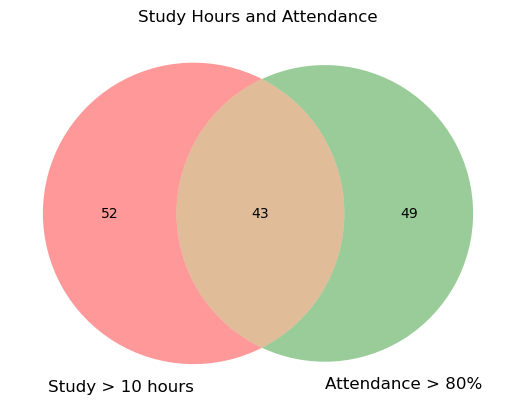

In [17]:
# Students who study more than 10 hours
ta = len(DF[DF["study_hours"] > 10])

# Students who have more than 80% attendance
tb = len(DF[DF["attendance"] > 80])

# Students who study more than 10 hours AND have more than 80% attendance
c = len(DF[(DF["study_hours"] > 10) & (DF["attendance"] > 80)])

# Study more than 10 hours only
a = ta - c

# Attendance more than 80% only
b = tb - c

# Create Venn diagram
venn2(
    subsets=(a, b, c),
    set_labels=("Study > 10 hours", "Attendance > 80%")
)

plt.title("Study Hours and Attendance")
plt.show()

# ****Contingency table & Probability Calculation.****

In [18]:
Contingency_table = pd.crosstab(DF["group_discussion"] , DF["final_exam_pass"] , margins=True)
Contingency_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,76,19,95
Yes,67,38,105
All,143,57,200


# ****Joint Probability.****

# Group Discussion = Yes AND Pass

In [20]:
Contingency_probability = pd.crosstab(DF["group_discussion"] , DF["final_exam_pass"] , margins=True , normalize = "all")
Contingency_probability

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.380,0.095,0.475
Yes,0.335,0.190,0.525
All,0.715,0.285,1.000


# ****Marginal Probability.****
# Pass

In [23]:
p = len(DF[DF["final_exam_pass"]=="Pass"]) / len(DF)
print("Probability:" , p)

Probability: 0.285


In [ ]:
# ****Conditional Probability.****

In [24]:
yes_students = len(DF[DF["group_discussion"] == "Yes"])

yes_and_pass = len(
    DF[
        (DF["group_discussion"] == "Yes") &
        (DF["final_exam_pass"] == "Pass")
    ])

conditional_probability = yes_and_pass / yes_students

print("Number of students with group discussion:", yes_students)
print("Students with group discussion and Pass:", yes_and_pass)
print("Probability of passing given group discussion:", conditional_probability)
print("Percentage:", conditional_probability * 100, "%")

Number of students with group discussion: 105
Students with group discussion and Pass: 38
Probability of passing given group discussion: 0.3619047619047619
Percentage: 36.19047619047619 %


# ****6. Understanding Relationships.*****
# Conditional Probability Interpretation
# Conditional probability tells us the probability of one event happening when we already know that another event has happened.

# In this project, P(Pass | Group Discussion = Yes) tells us the probability that a student passes the exam among students who participated in group discussions.

# ***Independent or Dependent ?***
# Two events are independent when the occurrence of one event does not affect the probability of the other event.

# ****We compare:****

# P(Pass | Group Discussion = Yes)

# with

# P(Pass)

# If the values are different, it suggests that the two events are dependent.

# Mutually Exclusive?
# The events are not mutually exclusive because a student can participate in group discussion and also pass the exam.

In [26]:
pass_probability = len(
    DF[DF["final_exam_pass"] == "Pass"]
) / len(DF)

print("P(Pass):", pass_probability*100,"%")
print("P(Pass | Group Discussion = Yes):", conditional_probability*100,"%")

P(Pass): 28.499999999999996 %
P(Pass | Group Discussion = Yes): 36.19047619047619 %


# ****7. Bayes Theorem.****

# Given:

# P(High Attendance | Pass) = 0.45

# P(High Attendance | Fail) = 0.17

# P(High Attendance) = 0.375

# We need to find:

# P(Pass | High Attendance)

In [28]:
P_high_given_pass = 0.45
P_high_given_fail = 0.17
P_high = 0.375

P_pass = (P_high - P_high_given_fail) / (P_high_given_pass - P_high_given_fail)

P_fail = 1 - P_pass

P_pass_given_high = (P_high_given_pass * P_pass) / P_high

print("P(Pass):", P_pass)
print("P(Fail):", P_fail)
print("P(Pass | High Attendance):", P_pass_given_high)

P(Pass): 0.732142857142857
P(Fail): 0.267857142857143
P(Pass | High Attendance): 0.8785714285714284


# ****Final Summary.****

# In this project, I used Python, Pandas, and NumPy to analyze the student dataset. First, I calculated basic probabilities like the probability of passing and failing the exam. Then I calculated empirical and theoretical probabilities.

# For the random variable, I considered the number of students passing out of 3 selected students and created its probability distribution. I also calculated the mean and variance.

# I created a Venn diagram to compare students studying more than 10 hours with students having more than 80% attendance. After that, I created a contingency table for group discussion and exam results and calculated joint, marginal, and conditional probabilities.

# Finally, I compared the probabilities to understand the relationship between group discussion and passing, and applied Bayes’ Theorem to calculate the probability of passing given high attendance.